# Historical Bootstrap Monte Carlo Simulation

In this notebook, we compare two Monte Carlo simulation methods:

- Parametric Monte Carlo
- Historical Bootstrap Monte Carlo

Parametric Monte Carlo assumes that asset returns follow a multivariate normal distribution based on historical mean returns and covariance.

Historical Bootstrap Monte Carlo samples directly from historical daily returns, allowing the simulation to preserve more realistic market behavior, including extreme observations and non-normal return patterns.

The objective is to compare how both methods estimate portfolio downside risk, Value at Risk, Expected Shortfall, and final portfolio value distribution.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project folders
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
IMAGES_DIR = PROJECT_ROOT / "images"

OUTPUTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

# Load daily returns
returns = pd.read_csv(
    DATA_DIR / "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

returns.head()

,GLD,QQQ,SPY,TLT
Date,,,,
2018-01-03,-0.002637,0.009717,0.006325,0.004782
2018-01-04,0.005127,0.001749,0.004215,-0.000159
2018-01-05,-0.001036,0.010043,0.006664,-0.002856
2018-01-08,-0.000160,0.003891,0.001829,-0.000637
2018-01-09,-0.004628,0.000062,0.002264,-0.013372


In [2]:
# Simulation settings
initial_portfolio_value = 10_000
n_simulations = 10_000
time_horizon = 252
trading_days = 252

# Balanced portfolio allocation
weights = pd.Series({
    "SPY": 0.40,
    "QQQ": 0.30,
    "TLT": 0.20,
    "GLD": 0.10
})

# Reorder weights to match returns columns
weights = weights[returns.columns]

weights

GLD    0.1
QQQ    0.3
SPY    0.4
TLT    0.2
dtype: float64

## Parametric Monte Carlo Simulation

The parametric approach generates simulated returns using the historical mean return vector and covariance matrix, assuming returns follow a multivariate normal distribution.

In [3]:
def run_parametric_monte_carlo(
    returns,
    weights,
    initial_value=10_000,
    n_simulations=10_000,
    time_horizon=252,
    random_seed=42
):
    """
    Runs a parametric Monte Carlo simulation using a multivariate normal distribution.
    """
    np.random.seed(random_seed)

    mean_returns = returns.mean()
    cov_matrix = returns.cov()

    simulated_asset_returns = np.random.multivariate_normal(
        mean=mean_returns,
        cov=cov_matrix,
        size=(n_simulations, time_horizon)
    )

    simulated_portfolio_returns = simulated_asset_returns @ weights.values

    portfolio_values = initial_value * np.cumprod(
        1 + simulated_portfolio_returns,
        axis=1
    )

    final_values = portfolio_values[:, -1]

    return portfolio_values, final_values

In [4]:
parametric_paths, parametric_final_values = run_parametric_monte_carlo(
    returns=returns,
    weights=weights,
    initial_value=initial_portfolio_value,
    n_simulations=n_simulations,
    time_horizon=time_horizon,
    random_seed=42
)

print("Parametric Monte Carlo completed.")
print(f"Average final value: ${parametric_final_values.mean():,.2f}")

Parametric Monte Carlo completed.
Average final value: $11,500.85


## Historical Bootstrap Monte Carlo Simulation

The bootstrap approach creates simulated paths by randomly sampling historical daily return observations with replacement.

Instead of assuming a normal distribution, this method reuses actual historical return patterns observed in the dataset.

In [5]:
def run_bootstrap_monte_carlo(
    returns,
    weights,
    initial_value=10_000,
    n_simulations=10_000,
    time_horizon=252,
    random_seed=42
):
    """
    Runs a historical bootstrap Monte Carlo simulation.

    Each simulated path is created by sampling historical daily return rows
    with replacement.
    """
    np.random.seed(random_seed)

    historical_returns = returns.values
    n_observations = historical_returns.shape[0]

    random_indices = np.random.randint(
        low=0,
        high=n_observations,
        size=(n_simulations, time_horizon)
    )

    sampled_asset_returns = historical_returns[random_indices]

    simulated_portfolio_returns = sampled_asset_returns @ weights.values

    portfolio_values = initial_value * np.cumprod(
        1 + simulated_portfolio_returns,
        axis=1
    )

    final_values = portfolio_values[:, -1]

    return portfolio_values, final_values

In [6]:
bootstrap_paths, bootstrap_final_values = run_bootstrap_monte_carlo(
    returns=returns,
    weights=weights,
    initial_value=initial_portfolio_value,
    n_simulations=n_simulations,
    time_horizon=time_horizon,
    random_seed=42
)

print("Bootstrap Monte Carlo completed.")
print(f"Average final value: ${bootstrap_final_values.mean():,.2f}")

Bootstrap Monte Carlo completed.
Average final value: $11,512.28


In [7]:
def calculate_simulation_risk_metrics(final_values, initial_value=10_000):
    """
    Calculates risk metrics from simulated final portfolio values.
    """
    simulated_returns = final_values / initial_value - 1

    mean_final_value = final_values.mean()
    median_final_value = np.median(final_values)

    probability_of_loss = np.mean(final_values < initial_value)

    var_95 = np.percentile(simulated_returns, 5)
    expected_shortfall_95 = simulated_returns[
        simulated_returns <= var_95
    ].mean()

    return {
        "Mean Final Value": mean_final_value,
        "Median Final Value": median_final_value,
        "Probability of Loss": probability_of_loss,
        "95% Value at Risk": var_95,
        "95% Expected Shortfall": expected_shortfall_95
    }

In [8]:
parametric_metrics = calculate_simulation_risk_metrics(
    parametric_final_values,
    initial_value=initial_portfolio_value
)

bootstrap_metrics = calculate_simulation_risk_metrics(
    bootstrap_final_values,
    initial_value=initial_portfolio_value
)

monte_carlo_comparison = pd.DataFrame({
    "Parametric Monte Carlo": parametric_metrics,
    "Bootstrap Monte Carlo": bootstrap_metrics
}).T

# Save results
monte_carlo_comparison.to_csv(
    OUTPUTS_DIR / "bootstrap_vs_parametric_monte_carlo.csv"
)

monte_carlo_comparison

,Mean Final Value,Median Final Value,Probability of Loss,95% Value at Risk,95% Expected Shortfall
Parametric Monte Carlo,11500.850986,11382.972590,0.1930,-0.111579,-0.164366
Bootstrap Monte Carlo,11512.280335,11378.924892,0.1951,-0.111066,-0.163727


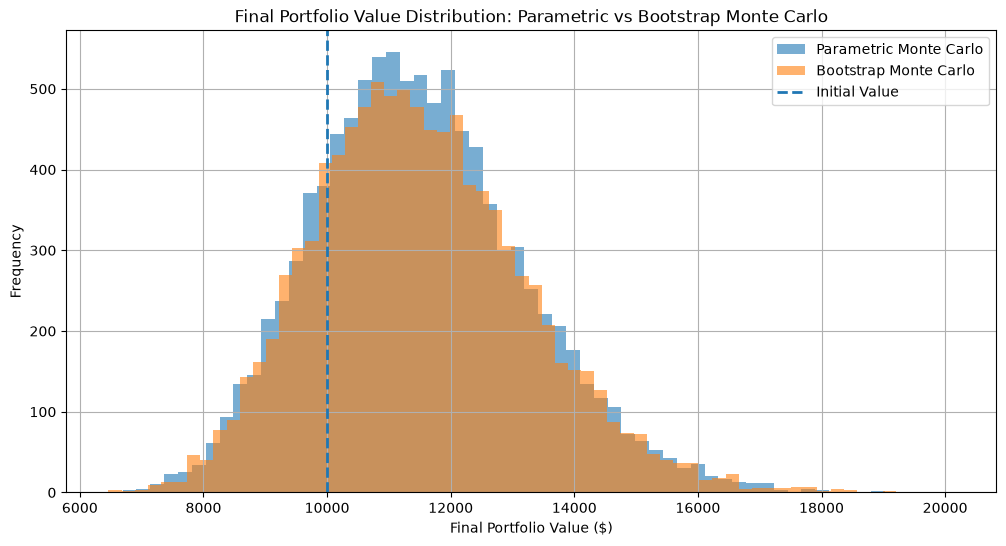

In [9]:
plt.figure(figsize=(12, 6))

plt.hist(
    parametric_final_values,
    bins=60,
    alpha=0.6,
    label="Parametric Monte Carlo"
)

plt.hist(
    bootstrap_final_values,
    bins=60,
    alpha=0.6,
    label="Bootstrap Monte Carlo"
)

plt.axvline(
    initial_portfolio_value,
    linestyle="--",
    linewidth=2,
    label="Initial Value"
)

plt.title("Final Portfolio Value Distribution: Parametric vs Bootstrap Monte Carlo")
plt.xlabel("Final Portfolio Value ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.savefig(
    IMAGES_DIR / "bootstrap_vs_parametric_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

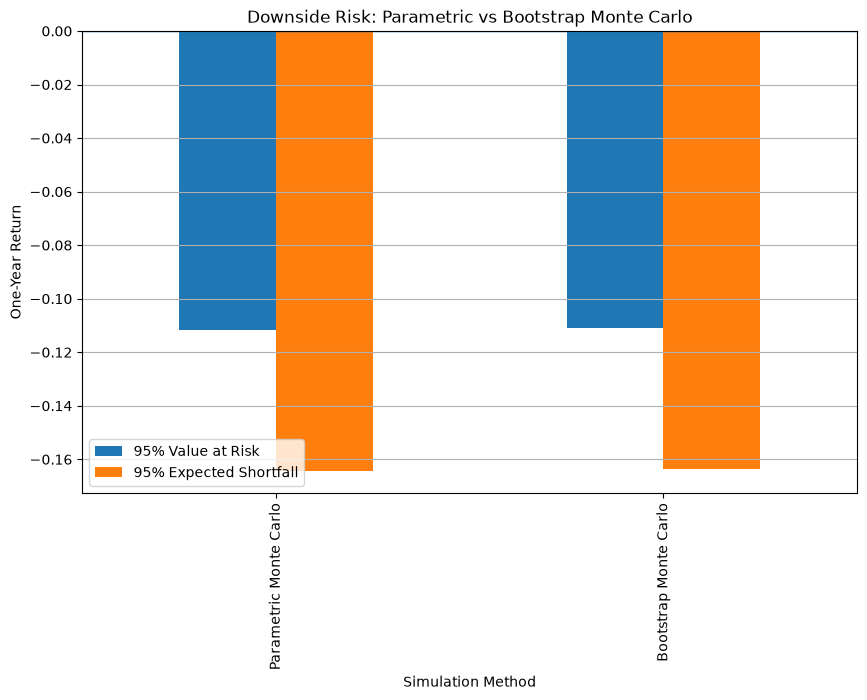

In [10]:
risk_metric_plot = monte_carlo_comparison[
    ["95% Value at Risk", "95% Expected Shortfall"]
]

ax = risk_metric_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Downside Risk: Parametric vs Bootstrap Monte Carlo")
plt.xlabel("Simulation Method")
plt.ylabel("One-Year Return")
plt.axhline(0, linewidth=1)
plt.grid(axis="y")

fig = ax.get_figure()
fig.savefig(
    IMAGES_DIR / "bootstrap_vs_parametric_downside_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

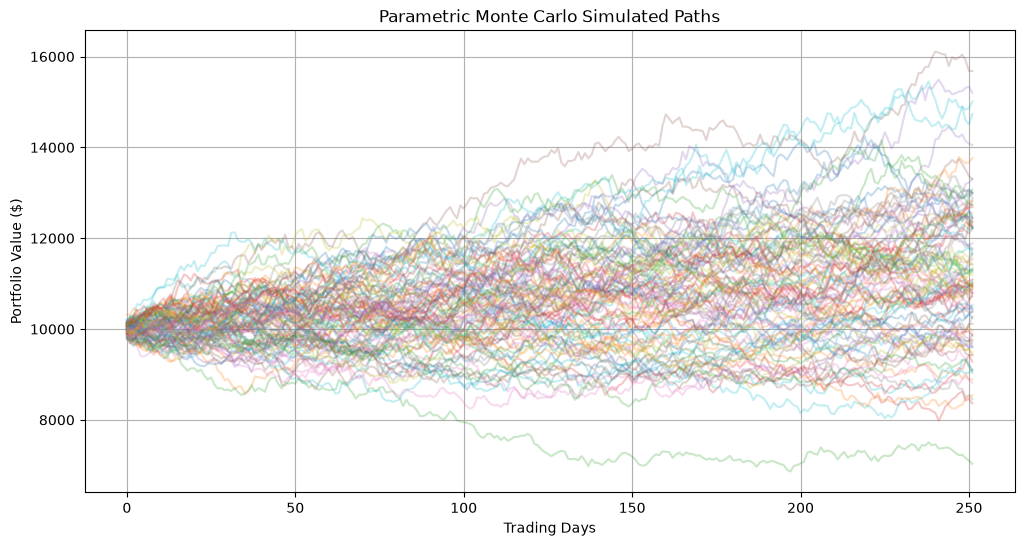

In [11]:
plt.figure(figsize=(12, 6))

for i in range(100):
    plt.plot(parametric_paths[i], alpha=0.25)

plt.title("Parametric Monte Carlo Simulated Paths")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value ($)")
plt.grid(True)

plt.savefig(
    IMAGES_DIR / "parametric_monte_carlo_paths.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

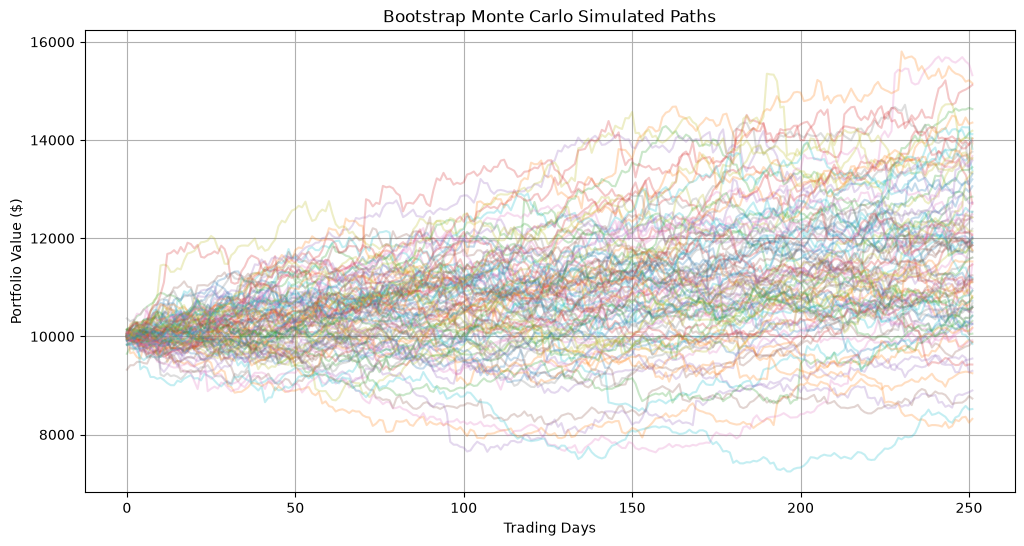

In [12]:
plt.figure(figsize=(12, 6))

for i in range(100):
    plt.plot(bootstrap_paths[i], alpha=0.25)

plt.title("Bootstrap Monte Carlo Simulated Paths")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value ($)")
plt.grid(True)

plt.savefig(
    IMAGES_DIR / "bootstrap_monte_carlo_paths.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Bootstrap Monte Carlo Interpretation

The comparison between Parametric Monte Carlo and Historical Bootstrap Monte Carlo highlights how different simulation assumptions can affect estimated portfolio risk.

The Parametric Monte Carlo method assumes that returns follow a multivariate normal distribution based on historical mean returns and covariance.

The Historical Bootstrap Monte Carlo method samples directly from historical return observations. This allows the simulation to preserve some empirical characteristics of market data, including extreme daily returns and non-normal behavior.

If the Bootstrap Monte Carlo produces worse Value at Risk or Expected Shortfall estimates, it suggests that historical return patterns contain downside risks that may not be fully captured by the parametric normal assumption.

Overall, this analysis improves the robustness of the project by comparing two different approaches to simulating future portfolio outcomes.